<a href="https://colab.research.google.com/github/jihoon0915-gif/-AI-BIGDATA-34-/blob/main/8_Regularization_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **L2 Regularization**

This notebook investigates regularization.

Work through the cells below, running each cell in turn. In various places you will see the words "TO DO". Follow the instructions at these places and make predictions about what is going to happen or write code to complete the functions.

In [9]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt

실제 underlying function은

$$
y = \sin(\pi x)
$$

라고 하겠습니다.

Training data에는 noise를 추가하고, sample은 **8개만** 사용합니다.

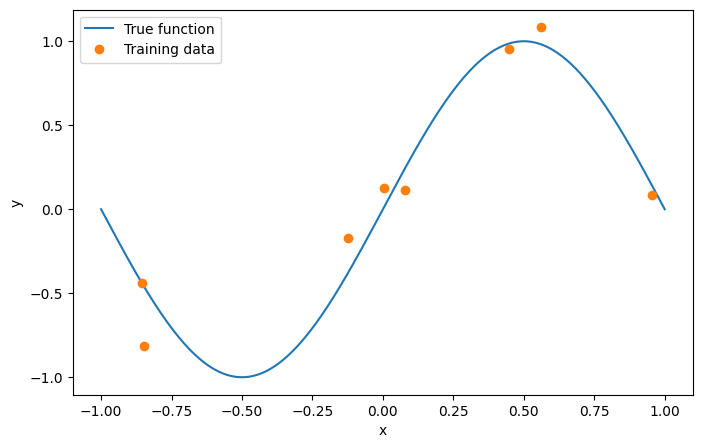

In [10]:
np.random.seed(7)

n_train = 8

x_train = np.sort(np.random.uniform(-1, 1, n_train))
y_train_true = np.sin(np.pi * x_train)

y_train = (y_train_true + 0.2 * np.random.randn(n_train))

# Test data에는 noise를 넣지 않음
x_test = np.linspace(-1, 1, 300)
y_test = np.sin(np.pi * x_test)

plt.figure(figsize=(8, 5))
plt.plot(x_test, y_test, label="True function")
plt.plot(x_train, y_train, "o", label="Training data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

18차 polynomial을 사용합니다.

$$
\hat{y}
=
w_0
+
w_1 x
+
w_2 x^2
+
\cdots
+
w_{18}x^{18}
$$

Parameter는 총 **19개**인데 training sample은 **8개**밖에 없습니다.

따라서 training data에 매우 복잡하게 맞출 수 있습니다.

Now let's
compute the sum of squares loss for the training data

In [11]:
degree = 18

def make_features(x, degree):
    X = np.zeros((len(x), degree + 1))

    for d in range(degree + 1):
        X[:, d] = x ** d

    return X


X_train = make_features(
    x_train,
    degree
)

X_test = make_features(
    x_test,
    degree
)

print("Number of training samples :", X_train.shape[0])
print("Number of parameters       :", X_train.shape[1])

Number of training samples : 8
Number of parameters       : 19


In [12]:
def compute_loss(X, y, w):
    y = y.reshape(-1, 1)
    prediction = X @ w
    return np.mean((prediction - y) ** 2)

def compute_gradient(X, y, w):
    y = y.reshape(-1, 1)
    prediction = X @ w
    gradient = (2 / X.shape[0] * X.T @ (prediction - y))

    return gradient

먼저 기존 Gradient Descent를 그대로 사용합니다.

$$
\boxed{
w
\leftarrow
w
-
\alpha
\frac{\partial L_{\text{data}}}{\partial w}
}
$$

여기서는 효과를 확실하게 보기 위해 충분히 많은 step을 반복합니다.

In [13]:
n_steps = 100000
alpha = 0.05

# Initialize parameters
w = np.zeros((degree + 1, 1))

step_history = []
train_loss_history = []
test_loss_history = []

for c_step in range(n_steps):

    # 1. Compute gradient
    gradient = compute_gradient(
        X_train,
        y_train,
        w
    )

    # 2. Gradient descent update
    w = w - alpha * gradient

    # Record losses
    if c_step % 500 == 0:

        step_history.append(c_step)

        train_loss_history.append(
            compute_loss(
                X_train,
                y_train,
                w
            )
        )

        test_loss_history.append(
            compute_loss(
                X_test,
                y_test,
                w
            )
        )


train_loss = compute_loss(X_train, y_train, w)
test_loss = compute_loss(X_test, y_test, w)

print("Without L2")
print("Training Loss :", train_loss)
print("Test Loss     :", test_loss)
print("||w||         :", np.linalg.norm(w[1:]))

Without L2
Training Loss : 0.003422789394143472
Test Loss     : 2.5269986687802795
||w||         : 5.6642582201731315


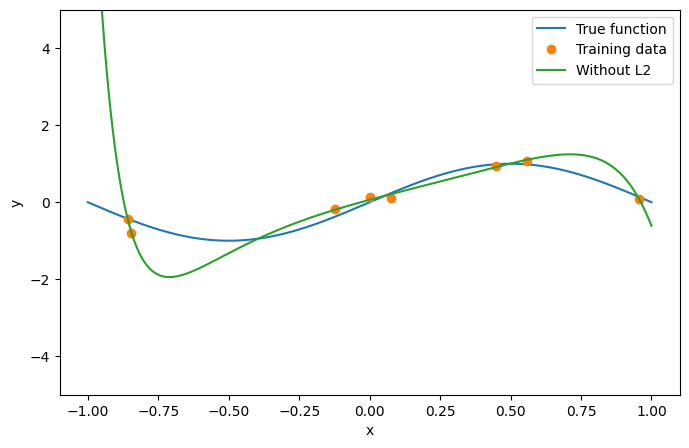

In [14]:
y_pred = X_test @ w

plt.figure(figsize=(8, 5))
plt.plot(x_test, y_test, label="True function")
plt.plot(x_train, y_train, "o", label="Training data")
plt.plot(x_test, y_pred, label="Without L2")
plt.ylim([-5, 5])
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

Loss에 weight penalty를 추가합니다.

$$
\boxed{
L_{\text{total}}
=
L_{\text{data}}
+
\lambda
\sum_{j=1}^{18}w_j^2
}
$$

In [15]:
lambda_ = 0.003

# Initialize parameters
w_l2 = np.zeros(
    (degree + 1, 1)
)

step_l2_history = []
train_loss_l2_history = []
test_loss_l2_history = []

for c_step in range(n_steps):

    # 1. Data loss gradient
    gradient = compute_gradient(X_train, y_train, w_l2)

    # 2. L2 gradient
    l2_gradient = 2 * lambda_ * w_l2

    # Do not regularize bias
    l2_gradient[0] = 0

    # 3. Total gradient
    total_gradient = (gradient + l2_gradient)

    # 4. Gradient descent update
    w_l2 = (w_l2 - alpha * total_gradient)

    # Record losses
    if c_step % 500 == 0:
        step_l2_history.append(c_step)
        train_loss_l2_history.append(compute_loss(X_train, y_train, w_l2))
        test_loss_l2_history.append(compute_loss(X_test, y_test, w_l2))


train_loss_l2 = compute_loss(X_train, y_train, w_l2)
test_loss_l2 = compute_loss(X_test, y_test, w_l2)

print("With L2")
print("Training Loss :", train_loss_l2)
print("Test Loss     :", test_loss_l2)
print("||w||         :", np.linalg.norm(w_l2[1:]))

With L2
Training Loss : 0.010395361367425426
Test Loss     : 0.10374420981108515
||w||         : 1.8908826206391023


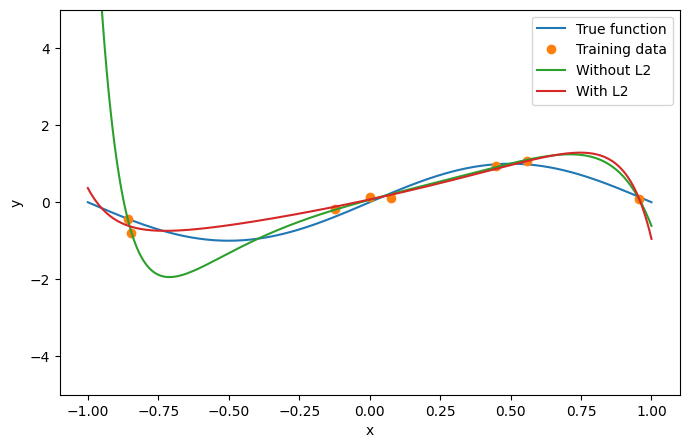

In [16]:
y_pred_no_reg = X_test @ w
y_pred_l2 = X_test @ w_l2

plt.figure(figsize=(8, 5))

plt.plot(x_test, y_test, label="True function")
plt.plot( x_train, y_train, "o", label="Training data")
plt.plot(x_test, y_pred_no_reg, label="Without L2")
plt.plot(x_test, y_pred_l2, label="With L2")
plt.ylim([-5, 5])
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()